# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [1]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [3]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [4]:
df.describe(include="object").T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


Reviso los valores únicos de todas las columnas, no solo las de texto, porque ID es numérica y también podría ser un identificador.

In [5]:
for col in df.columns:
    print(f"{col:10s} -> {df[col].nunique():6d} valores únicos")

ID         -> 135571 valores únicos
Name       -> 134732 valores únicos
Sex        ->      2 valores únicos
Age        ->     74 valores únicos
Height     ->     95 valores únicos
Weight     ->    220 valores únicos
Team       ->   1184 valores únicos
NOC        ->    230 valores únicos
Games      ->     51 valores únicos
Year       ->     35 valores únicos
Season     ->      2 valores únicos
City       ->     42 valores únicos
Sport      ->     66 valores únicos
Event      ->    765 valores únicos
Medal      ->      3 valores únicos


ID tiene 135.571 valores únicos sobre 271.116 filas, y Name 134.732. Las dos identifican al deportista, no predicen el peso. Las descarto.

Games parece ser Year y Season concatenadas, tipo "1992 Summer" = 1992 + Summer. Lo compruebo antes de descartarla.

In [6]:
print(df[["Games", "Year", "Season"]].head())
print("\n¿Games es igual a Year + Season en todas las filas?")
print(((df["Year"].astype(str) + " " + df["Season"]) == df["Games"]).all())

         Games  Year  Season
0  1992 Summer  1992  Summer
1  2012 Summer  2012  Summer
2  1920 Summer  1920  Summer
3  1900 Summer  1900  Summer
4  1988 Winter  1988  Winter

¿Games es igual a Year + Season en todas las filas?


True


La comparación da True en todas las filas, así que Games es redundante y sale.

Con City tengo una sospecha parecida: cada edición de los Juegos se hace en una sola ciudad, así que teniendo Year y Season ya sabría cuál es.

In [7]:
ciudades_por_juego = df.groupby("Games")["City"].nunique()
print("Ediciones con una sola ciudad:", (ciudades_por_juego == 1).sum())
print("Ediciones con más de una ciudad:", (ciudades_por_juego > 1).sum())
print("\nLa excepción es:")
print(ciudades_por_juego[ciudades_por_juego > 1])

Ediciones con una sola ciudad: 50
Ediciones con más de una ciudad: 1

La excepción es:
Games
1956 Summer    2
Name: City, dtype: int64


50 de las 51 ediciones tienen una sola ciudad sede. La única excepción es 1956 Summer, que aparece con dos porque las pruebas ecuestres se corrieron en Estocolmo por la cuarentena australiana para caballos.

Una excepción entre 51 no me parece razón para conservarla. City también sale.

Team y NOC parecen decir lo mismo, el país, pero el número de categorías no coincide.

In [8]:
print("Categorías de Team:", df["Team"].nunique())
print("Categorías de NOC :", df["NOC"].nunique())
print("\nAlgunos valores de Team para el NOC = USA:")
print(sorted(df.loc[df["NOC"] == "USA", "Team"].unique())[:10])

Categorías de Team: 1184
Categorías de NOC : 230

Algunos valores de Team para el NOC = USA:
['A North American Team', 'Angelita', 'Angerburg', 'Aphrodite', 'Atalanta Boat Club-1', 'Atalanta Boat Club-2', 'BLO Polo Club, Rugby', 'Babe', 'Bingo', 'Boston Archers']


Team tiene 1.184 categorías y NOC 230. Al mirar los valores se ve el problema: dentro de NOC = USA aparecen cosas como 'Atalanta Boat Club-1' o 'Angelita', que son clubes y botes.

Revisando el mapeo, 1.141 de las 1.184 categorías de Team corresponden a un solo NOC, así que Team es básicamente una versión más detallada y más sucia. Las 43 restantes son equipos mixtos tipo 'Australia/Great Britain'.

Ese detalle de más no dice nada sobre el peso y multiplica la cardinalidad por cinco. Me quedo con NOC.

Falta revisar Event. En los deportes de combate y de levantamiento se compite por categorías de peso, y esas categorías van escritas en el nombre del evento. Miro dos de esos deportes.

In [9]:
print(df.loc[df["Sport"] == "Weightlifting", "Event"].unique()[:8])
print()
print(df.loc[df["Sport"] == "Boxing", "Event"].unique()[:8])

["Weightlifting Women's Super-Heavyweight"
 "Weightlifting Men's Lightweight" "Weightlifting Men's Middleweight"
 "Weightlifting Men's Featherweight" "Weightlifting Women's Featherweight"
 "Weightlifting Men's Heavyweight" "Weightlifting Men's Flyweight"
 "Weightlifting Men's Light-Heavyweight"]



["Boxing Men's Light-Welterweight" "Boxing Men's Heavyweight"
 "Boxing Men's Flyweight" "Boxing Men's Middleweight"
 "Boxing Men's Featherweight" "Boxing Men's Lightweight"
 "Boxing Men's Welterweight" "Boxing Men's Light-Flyweight"]


In [10]:
categorias_peso = df["Event"].str.contains("weight|kg", case=False)
print("Registros cuyo Event nombra una categoría de peso:", categorias_peso.sum())
print(f"Es el {categorias_peso.mean() * 100:.1f}% del dataset")

Registros cuyo Event nombra una categoría de peso: 22746
Es el 8.4% del dataset


Ahí está. En Weightlifting, Boxing, Wrestling y Judo el nombre del evento trae la categoría de peso del deportista, y son 22.746 registros, el 8,4% del archivo.

Como la categoría se asigna según el peso, dejar Event sería darle la respuesta al modelo. Es fuga de datos, la descarto. Además siempre empieza con el valor de Sport, así que también era redundante.

In [11]:
print("Registros duplicados en el dataframe original:", df.duplicated().sum())

df = df.drop(columns=["ID", "Name", "Games", "City", "Team", "Event"])
print("\nColumnas que quedan:", list(df.columns))
print("Forma del dataframe:", df.shape)

Registros duplicados en el dataframe original: 1385

Columnas que quedan: ['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'Sport', 'Medal']
Forma del dataframe: (271116, 9)


Ahora reviso duplicados y nulos.

In [12]:
print("Registros duplicados:", df.duplicated().sum())

Registros duplicados: 83251


En el dataframe original había 1.385 duplicados. Después de descartar columnas salen 83.251, muchísimos más.

La razón es que un deportista compite en varios eventos dentro de unos mismos Juegos, y al quitar Event esas filas quedan idénticas. Si las dejo, un nadador que compitió en seis pruebas pesaría seis veces más que un futbolista que compitió en una. Las elimino.

In [13]:
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 187865


In [14]:
(df.isnull().sum() / df.shape[0] * 100).round(2).sort_values(ascending=False)

Medal     80.86
Weight    17.36
Height    16.48
Age        1.45
Sex        0.00
NOC        0.00
Year       0.00
Season     0.00
Sport      0.00
dtype: float64

Nulos después de quitar los duplicados:

- Medal 80,9%
- Weight 17,4%
- Height 16,5%
- Age 1,5%

Con Medal el enunciado ya dice qué hacer, y tiene sentido, porque si no hay medalla registrada es porque el deportista no ganó. El vacío no es un dato perdido.

Weight es distinto, porque es lo que quiero predecir. Imputarlo sería enseñarle al modelo una respuesta inventada, así que toca borrar esas filas.

In [15]:
df = df.dropna(subset=["Weight"])
print("Filas tras eliminar los nulos de Weight:", df.shape[0])
print("\nNulos que quedan (%):")
print((df.isnull().sum() / df.shape[0] * 100).round(2).sort_values(ascending=False))

Filas tras eliminar los nulos de Weight: 155259

Nulos que quedan (%):
Medal     81.43
Height     0.84
Age        0.46
Sex        0.00
Weight     0.00
NOC        0.00
Year       0.00
Season     0.00
Sport      0.00
dtype: float64


Al quitar los nulos de Weight, los de Height se cayeron de 16,5% a 0,84% y los de Age de 1,5% a 0,46%. O sea que casi todos venían de las mismas filas, fichas antiguas donde no anotaron ni talla ni peso.

Como queda menos del 1%, prefiero borrarlos a imputarlos. Height va a ser mi mejor predictora y no quiero meterle valores inventados.

In [16]:
df["Medal"] = df["Medal"].fillna("No medal")
df = df.dropna()
df = df.reset_index(drop=True)

print("Dataframe final:", df.shape)
print()
df.info()

Dataframe final: (153410, 9)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153410 entries, 0 to 153409
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     153410 non-null  object 
 1   Age     153410 non-null  float64
 2   Height  153410 non-null  float64
 3   Weight  153410 non-null  float64
 4   NOC     153410 non-null  object 
 5   Year    153410 non-null  int64  
 6   Season  153410 non-null  object 
 7   Sport   153410 non-null  object 
 8   Medal   153410 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 10.5+ MB


In [17]:
df["Medal"].value_counts()

Medal
No medal    124845
Bronze        9839
Silver        9459
Gold          9267
Name: count, dtype: int64

Resumen del punto 1

Variables que descarté:

- ID y Name, porque identifican al deportista y tienen casi un valor por fila.
- Games, porque es Year más Season, igual en el 100% de las filas.
- City, porque en 50 de 51 ediciones queda determinada por Year y Season.
- Team, porque es una versión más detallada y sucia de NOC, con 1.184 categorías contra 230, donde el detalle de más son clubes y embarcaciones.
- Event, porque filtra la respuesta: en 22.746 registros el nombre del evento incluye la categoría de peso.

Me quedé con Sex, Age, Height, Weight, NOC, Year, Season, Sport y Medal.

Sobre los duplicados, salieron 83.251 después de descartar columnas, generados por la salida de Event. Los eliminé para que los deportistas de varios eventos no queden sobrerrepresentados.

Sobre los nulos, borré los de Weight por ser la variable objetivo, y después los de Height y Age, que quedaron por debajo del 1%. Los de Medal los llené con 'No medal'.

El dataframe quedó en 153.410 filas y 9 columnas, sin nulos.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [18]:
cat_vars = df.select_dtypes(include="object").columns

for var in cat_vars:
    print(f"{var:8s} -> {df[var].nunique():4d} categorías")

Sex      ->    2 categorías
NOC      ->  226 categorías
Season   ->    2 categorías
Sport    ->   56 categorías
Medal    ->    4 categorías


In [19]:
print(df["Sex"].value_counts())
print()
print(df["Season"].value_counts())

Sex
M    106187
F     47223
Name: count, dtype: int64

Season
Summer    128512
Winter     24898
Name: count, dtype: int64


Sex y Season tienen dos categorías cada una y no hay orden entre ellas: ser hombre no es "más" que ser mujer, ni Summer va antes que Winter. Son nominales binarias.

In [20]:
df["Medal"].value_counts()

Medal
No medal    124845
Bronze        9839
Silver        9459
Gold          9267
Name: count, dtype: int64

Medal es el caso distinto, porque sus 4 categorías sí tienen jerarquía. No tener medalla es menos que bronce, bronce menos que plata y plata menos que oro.

Es la única ordinal del dataset. El orden que voy a usar es No medal, Bronze, Silver, Gold.

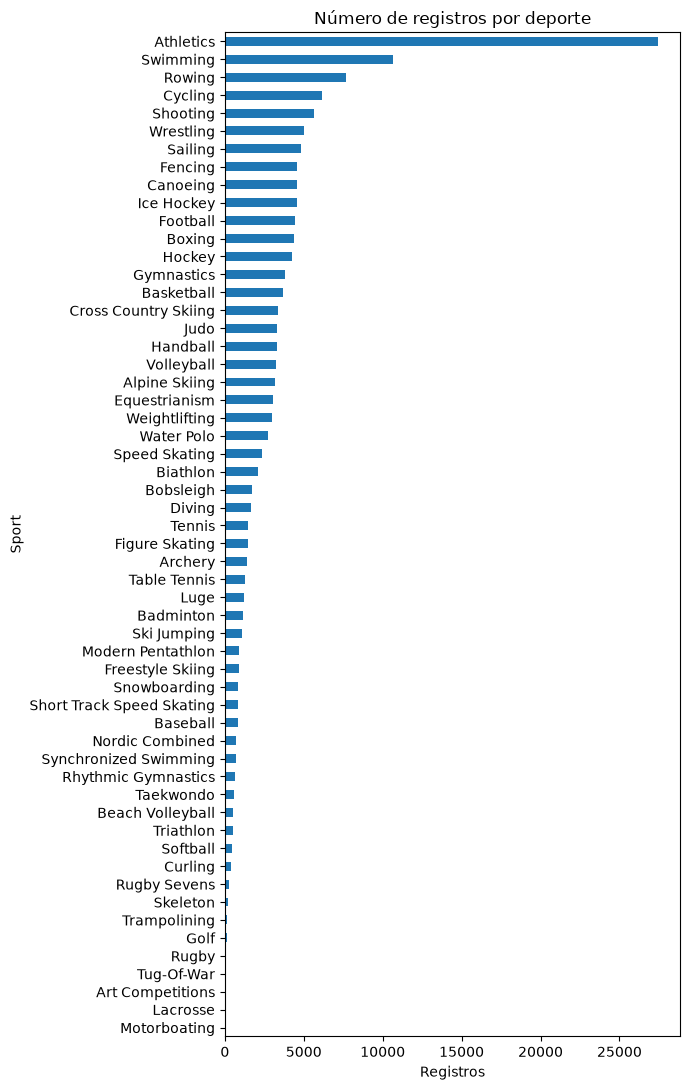

In [21]:
import matplotlib.pyplot as plt

conteo_sport = df["Sport"].value_counts().sort_values()
conteo_sport.plot(kind="barh", figsize=(7, 11))
plt.title("Número de registros por deporte")
plt.xlabel("Registros")
plt.tight_layout()
plt.show()

In [22]:
print("Los 5 deportes con más registros:")
print(df["Sport"].value_counts().head(5))
print("\nLos 5 deportes con menos registros:")
print(df["Sport"].value_counts().tail(5))

Los 5 deportes con más registros:
Sport
Athletics    27464
Swimming     10675
Rowing        7647
Cycling       6129
Shooting      5652
Name: count, dtype: int64

Los 5 deportes con menos registros:
Sport
Rugby               29
Tug-Of-War          20
Art Competitions    15
Lacrosse             2
Motorboating         1
Name: count, dtype: int64


Sport tiene 56 categorías y en el gráfico se ve lo desbalanceada que está la distribución: Athletics se lleva 27.464 registros y Swimming 10.675, mientras que abajo hay deportes con casi nada. Motorboating tiene 1 registro, Lacrosse 2 y Art Competitions 15.

Esas de abajo son categorías atípicas. Con un One-Hot cada una quedaría como una columna de casi puros ceros.

In [23]:
conteo_noc = df["NOC"].value_counts()
print("Categorías de NOC:", conteo_noc.size)
print("\nLos 5 países con más registros:")
print(conteo_noc.head(5))
print("\nLos 5 países con menos registros:")
print(conteo_noc.tail(5))

Categorías de NOC: 226

Los 5 países con más registros:
NOC
USA    11196
GBR     5701
FRA     5649
GER     5625
CAN     5578
Name: count, dtype: int64

Los 5 países con menos registros:
NOC
SSD    3
YMD    2
SAA    2
UAR    1
NFL    1
Name: count, dtype: int64


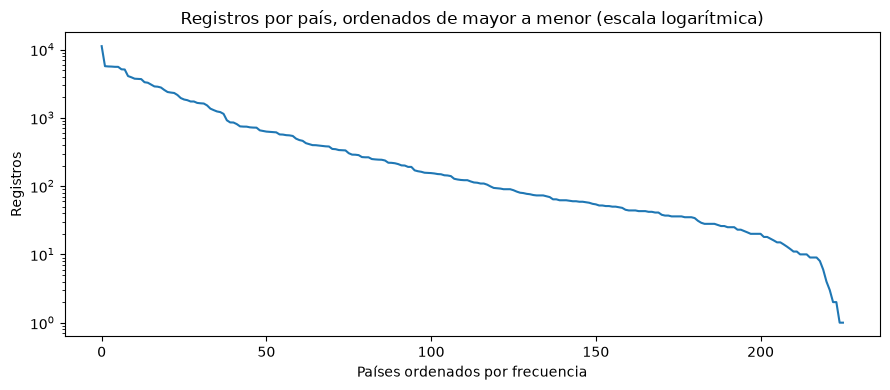

In [24]:
conteo_noc.reset_index(drop=True).plot(figsize=(9, 4), logy=True)
plt.title("Registros por país, ordenados de mayor a menor (escala logarítmica)")
plt.xlabel("Países ordenados por frecuencia")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

El gráfico muestra la cola larga de NOC. Unos pocos países concentran casi todos los registros, USA con 11.196, y después la curva se desploma hasta códigos con 1 o 2, que suelen ser comités que ya no existen.

Cuento cuántas categorías caen por debajo de un umbral.

In [25]:
for var in ["NOC", "Sport"]:
    conteo = df[var].value_counts()
    raras = conteo[conteo < 1000]
    print(f"{var}: {raras.size} de {conteo.size} categorías tienen menos de 1000 registros, "
          f"y entre todas son el {raras.sum() / df.shape[0] * 100:.2f}% de los datos")

NOC: 188 de 226 categorías tienen menos de 1000 registros, y entre todas son el 21.55% de los datos
Sport: 22 de 56 categorías tienen menos de 1000 registros, y entre todas son el 6.33% de los datos


NOC es el caso grave, con 188 de sus 226 categorías por debajo de 1000 registros. Un One-Hot directo me daría 226 columnas casi todas vacías.

Para eso sirve el parámetro min_frequency del OneHotEncoder, que agrupa las categorías poco frecuentes en una sola columna. Miro cómo quedaría.

In [26]:
from sklearn.preprocessing import OneHotEncoder

for var in ["NOC", "Sport"]:
    ohe = OneHotEncoder(sparse_output=False, min_frequency=1000)
    ohe.fit(df[[var]])
    print(f"{var}: de {df[var].nunique()} categorías pasa a "
          f"{len(ohe.get_feature_names_out())} columnas")
    print(f"   agrupa {len(ohe.infrequent_categories_[0])} categorías como infrecuentes\n")

NOC: de 226 categorías pasa a 39 columnas
   agrupa 188 categorías como infrecuentes

Sport: de 56 categorías pasa a 35 columnas
   agrupa 22 categorías como infrecuentes



Resumen del punto 2

Por tipo:

- Ordinal hay una sola, Medal, con el orden No medal, Bronze, Silver, Gold.
- Nominales son Sex, Season, Sport y NOC.

Por cardinalidad, las altas son NOC con 226 categorías y Sport con 56. Sex y Season tienen 2, y Medal 4, así que esas no dan problema.

Categorías atípicas encontré en las dos de alta cardinalidad. NOC tiene 188 categorías con menos de 1000 registros, que son el 21,6% de los datos, y Sport tiene 22, el 6,3%. Los casos extremos son Motorboating con 1 registro y Lacrosse con 2.

Procesamiento que le daría a cada una:

- Sex y Season con OneHotEncoder y drop='if_binary', porque teniendo dos categorías basta una columna.
- Medal con OrdinalEncoder pasándole el orden a mano. Con One-Hot perdería la jerarquía, que es justo lo que la hace útil.
- Sport con OneHotEncoder y min_frequency=1000, que la deja en 35 columnas en vez de 56.
- NOC igual, que la baja de 226 a 39 columnas. También pensé en TargetEncoder, que la dejaría en una sola columna, pero lo descarto porque usa la variable objetivo para codificar y el resultado no se puede leer.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [27]:
num_vars = df.select_dtypes(include="number").columns
print("Variables cuantitativas:", list(num_vars))
df[num_vars].describe().round(2)

Variables cuantitativas: ['Age', 'Height', 'Weight', 'Year']


,Age,Height,Weight,Year
count,153410.00,153410.00,153410.00,153410.00
mean,25.47,176.52,72.30,1990.45
std,5.43,10.38,14.71,20.13
min,11.00,127.00,25.00,1896.00
25%,22.00,170.00,62.00,1976.00
50%,25.00,176.00,71.00,1996.00
75%,28.00,183.00,81.00,2008.00
max,71.00,226.00,214.00,2016.00


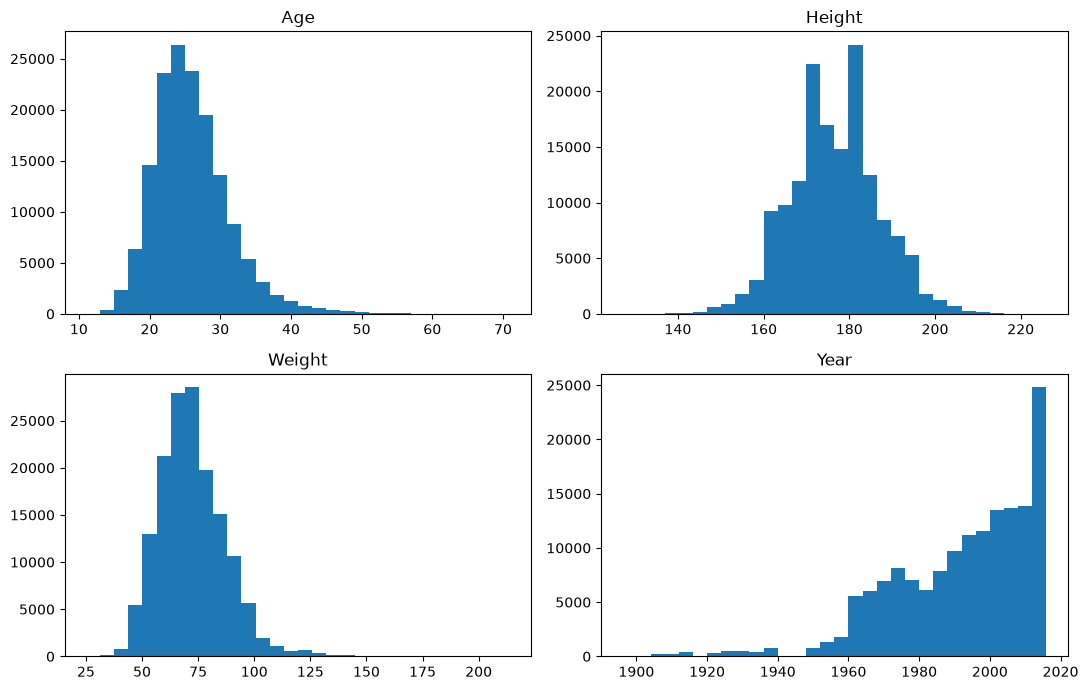

In [28]:
df[num_vars].hist(figsize=(11, 7), bins=30, grid=False, layout=(2, 2))
plt.tight_layout()
plt.show()

Para la normalidad uso Kolmogorov-Smirnov junto con la asimetría y la curtosis.

Un aviso sobre el código: la forma que vimos en clase, kstest(x, 'norm', args=(media, desviación)), me lanza un TypeError con la versión de scipy que tengo instalada. La reescribí estandarizando la variable y comparándola contra la normal estándar, que viene siendo la misma prueba.

In [29]:
from scipy.stats import kstest

for var in num_vars:
    __, p_value = kstest((df[var] - df[var].mean()) / df[var].std(), "norm")
    print(f"{var}:")
    print(f"   asimetría: {df[var].skew():6.3f}")
    print(f"   curtosis : {df[var].kurt():6.3f}")
    print(f"   valor p de Kolmogorov-Smirnov: {p_value:.3g}\n")

Age:
   asimetría:  1.182
   curtosis :  3.254
   valor p de Kolmogorov-Smirnov: 0

Height:
   asimetría:  0.071
   curtosis :  0.125
   valor p de Kolmogorov-Smirnov: 3.9e-149

Weight:
   asimetría:  0.841
   curtosis :  1.993
   valor p de Kolmogorov-Smirnov: 0



Year:
   asimetría: -1.013
   curtosis :  1.289
   valor p de Kolmogorov-Smirnov: 0



El test me rechaza la normalidad en las cuatro variables, con valores p que salen en 0. Pero con 153.410 registros iba a rechazar cualquier cosa, porque detecta hasta la desviación más mínima, así que no me sirve por sí solo. Me apoyo en la asimetría, la curtosis y la forma del histograma.

- Height tiene asimetría 0,07 y curtosis 0,13, o sea simétrica y sin colas pesadas. El histograma sale acampanado.
- Age tiene asimetría 1,18, sesgada a la derecha, con una cola de deportistas mayores.
- Weight tiene asimetría 0,84, también a la derecha pero menos marcada.
- Year tiene asimetría -1,01, sesgada al otro lado porque hay muchos más registros de ediciones recientes. Además solo tiene 35 valores distintos, así que se comporta como discreta.

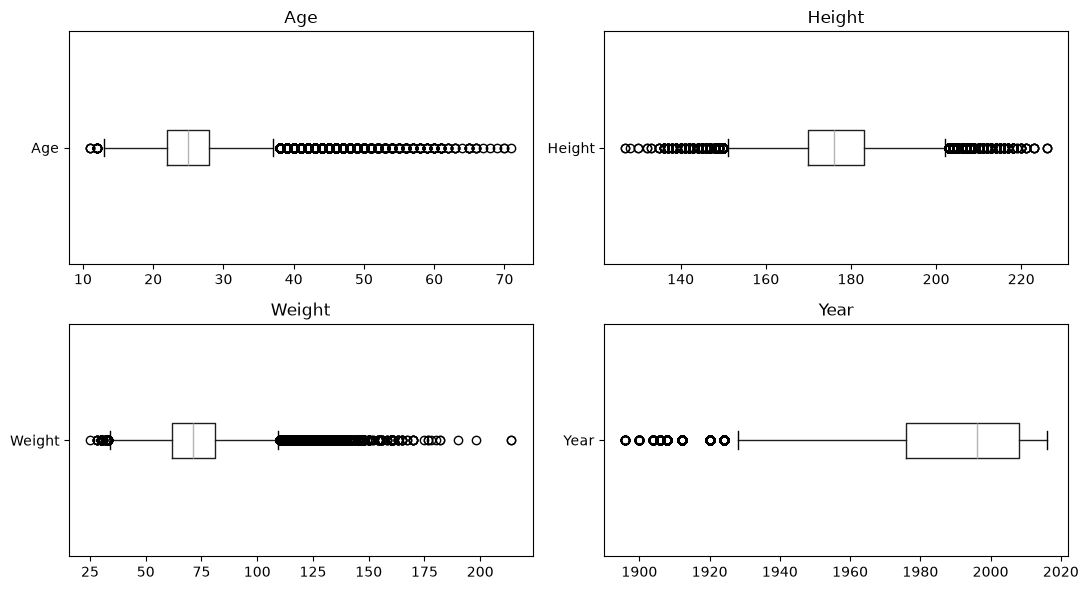

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
for i, var in enumerate(num_vars):
    df.boxplot(column=var, grid=False, vert=False, ax=ax[i // 2, i % 2])
    ax[i // 2, i % 2].set_title(var)
plt.tight_layout()
plt.show()

In [31]:
print("Datos atípicos por el método del rango intercuartílico:\n")
for var in num_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    atipicos = ((df[var] < limite_inferior) | (df[var] > limite_superior)).sum()
    print(f"{var}: límites [{limite_inferior:.1f}, {limite_superior:.1f}], "
          f"{atipicos} atípicos ({atipicos / df.shape[0] * 100:.2f}%), "
          f"rango real [{df[var].min():.0f}, {df[var].max():.0f}]")

Datos atípicos por el método del rango intercuartílico:

Age: límites [13.0, 37.0], 4499 atípicos (2.93%), rango real [11, 71]
Height: límites [150.5, 202.5], 2094 atípicos (1.36%), rango real [127, 226]
Weight: límites [33.5, 109.5], 2780 atípicos (1.81%), rango real [25, 214]
Year: límites [1928.0, 2056.0], 1729 atípicos (1.13%), rango real [1896, 2016]


Resumen del punto 3

La única aproximadamente normal es Height. Age, Weight y Year no lo son.

Datos atípicos por el rango intercuartílico:

- Age tiene 4.499, el 2,93%, con límites en 13 y 37. De esos, 4.480 están por encima de 37 años y llegan hasta 71, y 19 por debajo de 13.
- Weight tiene 2.780, el 1,81%, con límites en 33,5 y 109,5. Son 2.725 por encima, hasta 214 kg, y 55 por debajo.
- Height tiene 2.094, el 1,36%, con límites en 150,5 y 202,5 y un rango real de 127 a 226 cm.
- Year tiene 1.729, el 1,13%. Como el límite superior queda en 2056, por encima del máximo real, todos son ediciones anteriores a 1928.

Ninguno de estos atípicos es un error de digitación. Un levantador de 214 kg, un gimnasta de 127 cm y los Juegos de 1896 son casos reales, así que no los voy a borrar. Lo que hago es escoger un procesamiento que no se deje arrastrar por ellos.

Procesamiento que le daría a cada una:

- Height con StandardScaler, porque es la más cercana a una normal y tiene pocos extremos.
- Age con PowerTransformer, para acercarla a una normal, ya que es la más sesgada. También serviría RobustScaler, que usa mediana y rango intercuartílico y por eso los extremos no lo mueven.
- Year con StandardScaler. No tiene sentido intentar normalizarla, es casi discreta.
- Weight no lleva ninguno, es la variable objetivo.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [32]:
correlaciones = df[["Age", "Height", "Weight", "Year"]].corr()
correlaciones.round(3)

,Age,Height,Weight,Year
Age,1.000,0.086,0.164,0.075
Height,0.086,1.000,0.776,0.027
Weight,0.164,0.776,1.000,0.004
Year,0.075,0.027,0.004,1.000


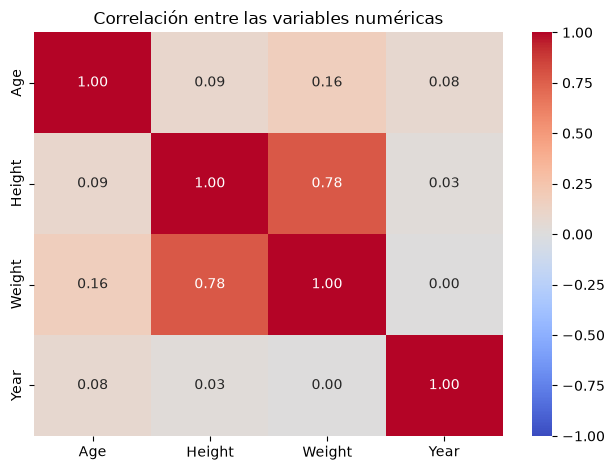

In [33]:
import seaborn as sns

sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre las variables numéricas")
plt.tight_layout()
plt.show()

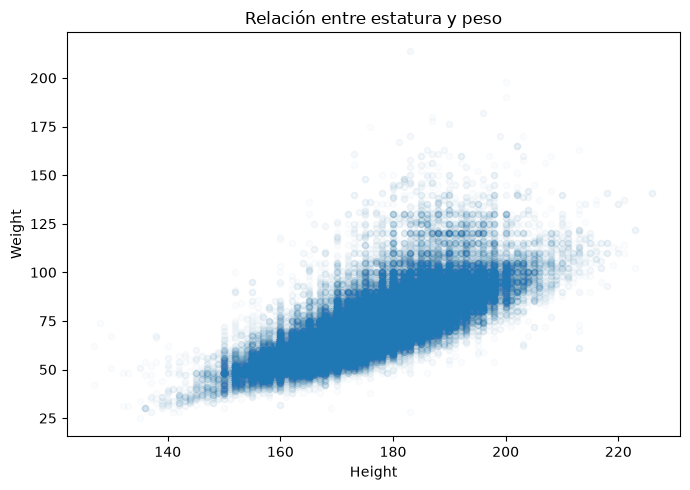

In [34]:
df.plot(kind="scatter", x="Height", y="Weight", alpha=0.02, figsize=(7, 5))
plt.title("Relación entre estatura y peso")
plt.tight_layout()
plt.show()

Height da 0,776 de correlación con el peso, que es la relación más fuerte del dataset y se ve clarísima en el gráfico de dispersión.

Age da 0,164, positiva pero floja. Y Year da 0,004, o sea que no hay relación lineal entre el año de la edición y el peso. El promedio sí varía de una edición a otra, pero sin tendencia sostenida, y por eso la correlación se anula.

Sex
F    61.50
M    77.11
Name: Weight, dtype: float64


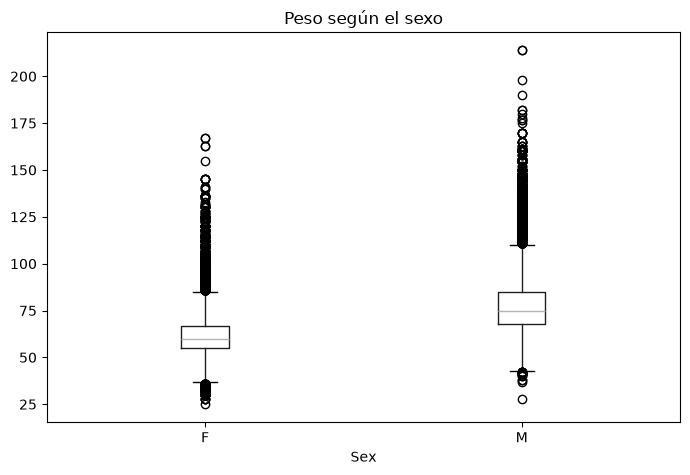

In [35]:
print(df.groupby("Sex")["Weight"].mean().round(2))

df.boxplot(column="Weight", by="Sex", grid=False, figsize=(7, 5))
plt.title("Peso según el sexo")
plt.suptitle("")
plt.tight_layout()
plt.show()

La diferencia por sexo es grande. Los hombres pesan 77,11 kg en promedio y las mujeres 61,50, más de 15 kg, y las cajas del boxplot casi no se solapan.

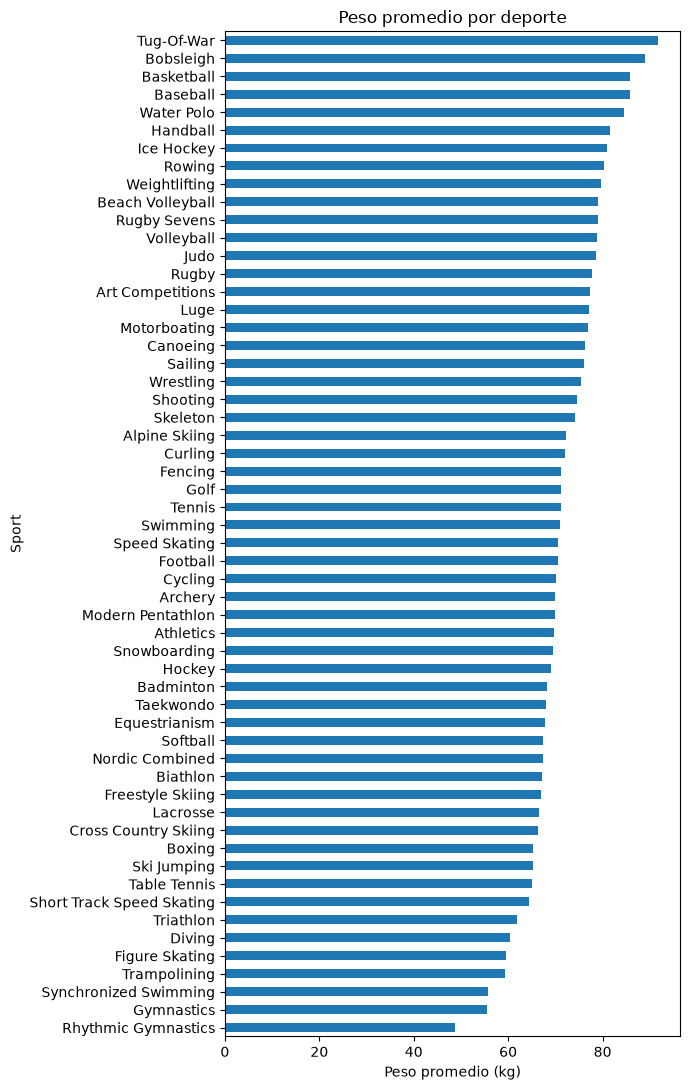

In [36]:
peso_por_deporte = df.groupby("Sport")["Weight"].mean().sort_values()

peso_por_deporte.plot(kind="barh", figsize=(7, 11))
plt.title("Peso promedio por deporte")
plt.xlabel("Peso promedio (kg)")
plt.tight_layout()
plt.show()

In [37]:
print("Los 5 deportes con menor peso promedio:")
print(peso_por_deporte.head(5).round(2))
print("\nLos 5 deportes con mayor peso promedio:")
print(peso_por_deporte.tail(5).round(2))

Los 5 deportes con menor peso promedio:
Sport
Rhythmic Gymnastics      48.76
Gymnastics               55.60
Synchronized Swimming    55.74
Trampolining             59.32
Figure Skating           59.53
Name: Weight, dtype: float64

Los 5 deportes con mayor peso promedio:
Sport
Water Polo    84.57
Baseball      85.72
Basketball    85.79
Bobsleigh     88.91
Tug-Of-War    91.80
Name: Weight, dtype: float64


Con Sport la variación es todavía mayor, desde 48,76 kg en gimnasia rítmica hasta 91,80 en tiro de cuerda. Más de 40 kg entre extremos, lo cual tiene sentido porque cada deporte favorece un tipo de cuerpo.

In [38]:
print("Peso promedio por Medal:")
print(df.groupby("Medal")["Weight"].mean().round(2))
print("\nPeso promedio por Season:")
print(df.groupby("Season")["Weight"].mean().round(2))

Peso promedio por Medal:
Medal
Bronze      73.65
Gold        74.57
No medal    71.91
Silver      73.86
Name: Weight, dtype: float64

Peso promedio por Season:
Season
Summer    72.34
Winter    72.09
Name: Weight, dtype: float64


In [39]:
print("Qué tanto varía el peso promedio entre las categorías de cada variable:\n")
for var in ["Sport", "NOC", "Sex", "Medal", "Season"]:
    print(f"{var:8s} -> desviación estándar de las medias: "
          f"{df.groupby(var)['Weight'].mean().std():.2f} kg")

Qué tanto varía el peso promedio entre las categorías de cada variable:

Sport    -> desviación estándar de las medias: 8.45 kg
NOC      -> desviación estándar de las medias: 6.26 kg
Sex      -> desviación estándar de las medias: 11.03 kg
Medal    -> desviación estándar de las medias: 1.13 kg
Season   -> desviación estándar de las medias: 0.18 kg


Resumen del punto 4

Para poder comparar las categóricas entre sí miro qué tanto varía el peso promedio entre sus categorías. Si una variable separa bien a los deportistas por peso, esa desviación tiene que salir alta.

Las que sí parecen servir:

- Height, con 0,776 de correlación. Es de lejos la relación más fuerte.
- Sex, con 11,03 kg de desviación entre medias, la más alta de las categóricas. Son 15,6 kg de diferencia entre hombres y mujeres.
- Sport, con 8,45 kg. Va de 48,76 kg en gimnasia rítmica a 91,80 en tiro de cuerda.
- NOC, con 6,26 kg. Esta la tomo con reserva, porque parte de esa variación debe venir de países con pocos registros, donde el promedio se mueve por nada.

Las que no:

- Age, con 0,164 de correlación.
- Medal, con 1,13 kg de desviación. Los promedios van de 71,91 a 74,57 kg, menos de 3 kg entre ganar oro y no ganar nada. Eso sí, el orden que propuse en el punto 2 se sostiene con los datos, porque el peso promedio crece de forma monótona (71,91, luego 73,65, luego 73,86 y por último 74,57), lo que confirma tratarla como ordinal aunque la diferencia sea pequeña. La voy a incluir igual porque el punto 5 pide una característica ordinal y es la única que tengo.
- Season, con 0,18 kg de desviación. 72,34 kg en verano contra 72,09 en invierno.
- Year, con 0,004 de correlación.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

Sobre el modelo que voy a usar

El enunciado dice al principio que hay que tener en cuenta que Weight es numérica, pero más abajo pide un modelo de regresión logística. Eso me confundió, así que lo repasé.

La regresión logística es un modelo de clasificación, predice categorías y no números, así que no aplica a una variable continua como el peso. Lo que corresponde es una regresión lineal.

Voy a usar Ridge, que es una regresión lineal regularizada: penaliza los coeficientes grandes a través del parámetro alpha. La prefiero sobre la lineal simple porque el preprocesamiento genera decenas de columnas One-Hot correlacionadas entre sí, y la regularización las mantiene bajo control.

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Weight"])
y = df["Weight"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1, train_size=0.8
    )

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (122728, 8)
Tamaño del conjunto de prueba: (30682, 8)


Para la primera versión escojo estas 5, según lo que salió en el análisis bivariado:

- Height, numérica, la de mayor correlación con el peso.
- Age, numérica, que aporta poco pero es la otra que tengo.
- Sex, nominal, la categórica que más separa los pesos con 11,03 kg de desviación.
- Sport, nominal, la segunda que más separa con 8,45 kg.
- Medal, ordinal, que incluyo para cumplir el requisito del enunciado aunque su poder predictivo sea bajo.

Con eso cumplo el mínimo de una ordinal y dos nominales. El procesamiento es el que definí en los puntos 2 y 3.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)

orden_medallas = [["No medal", "Bronze", "Silver", "Gold"]]

preprocessor = ColumnTransformer(transformers=[
    ("altura", StandardScaler(), ["Height"]),
    ("edad", PowerTransformer(), ["Age"]),
    ("sexo", OneHotEncoder(drop="if_binary", sparse_output=False), ["Sex"]),
    ("deporte", OneHotEncoder(sparse_output=False, handle_unknown="ignore",
                              min_frequency=1000), ["Sport"]),
    ("medalla", OrdinalEncoder(categories=orden_medallas, dtype="int"), ["Medal"]),
    ], remainder="drop")

preprocessor

,transformers,"[('altura', ...), ('edad', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


Al OneHotEncoder de Sport le puse handle_unknown='ignore' porque hay deportes con 1 o 2 registros que perfectamente pueden quedar solo en el conjunto de prueba. Sin ese parámetro el codificador revienta al encontrarse una categoría que no vio entrenando.

In [42]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
    ])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('altura', ...), ('edad', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
print("R² en el conjunto de entrenamiento:", round(pipeline.score(X_train, y_train), 4))
print("R² en el conjunto de prueba:", round(pipeline.score(X_test, y_test), 4))

R² en el conjunto de entrenamiento: 0.6956
R² en el conjunto de prueba: 0.6901


In [44]:
from sklearn.metrics import root_mean_squared_error

print("RMSE en el conjunto de prueba:",
      round(root_mean_squared_error(y_test, pipeline.predict(X_test)), 3), "kg")

RMSE en el conjunto de prueba: 8.231 kg


In [45]:
caracteristicas = pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Número de características con las que realmente se entrenó el modelo:",
      len(caracteristicas))
print()
print(caracteristicas)

Número de características con las que realmente se entrenó el modelo: 36

['altura__Height' 'edad__Age' 'sexo__Sex_M' 'deporte__Sport_Alpine Skiing'
 'deporte__Sport_Archery' 'deporte__Sport_Athletics'
 'deporte__Sport_Basketball' 'deporte__Sport_Biathlon'
 'deporte__Sport_Bobsleigh' 'deporte__Sport_Boxing'
 'deporte__Sport_Canoeing' 'deporte__Sport_Cross Country Skiing'
 'deporte__Sport_Cycling' 'deporte__Sport_Diving'
 'deporte__Sport_Equestrianism' 'deporte__Sport_Fencing'
 'deporte__Sport_Figure Skating' 'deporte__Sport_Football'
 'deporte__Sport_Gymnastics' 'deporte__Sport_Handball'
 'deporte__Sport_Hockey' 'deporte__Sport_Ice Hockey' 'deporte__Sport_Judo'
 'deporte__Sport_Rowing' 'deporte__Sport_Sailing'
 'deporte__Sport_Shooting' 'deporte__Sport_Speed Skating'
 'deporte__Sport_Swimming' 'deporte__Sport_Table Tennis'
 'deporte__Sport_Tennis' 'deporte__Sport_Volleyball'
 'deporte__Sport_Water Polo' 'deporte__Sport_Weightlifting'
 'deporte__Sport_Wrestling' 'deporte__Sport_infreque

Resultados del primer modelo

El R² dio 0,6956 en entrenamiento y 0,6901 en prueba, y el RMSE 8,231 kg. Los dos R² son casi iguales, así que el modelo no está sobreajustado. Explica cerca del 69% de la variabilidad del peso y se equivoca unos 8 kg en promedio.

Sobre el número de características, escogí 5 columnas pero el modelo se entrenó con 36. La diferencia la hace el procesamiento:

- Height y Age aportan una cada una.
- Sex aporta una sola, porque con drop='if_binary' queda únicamente la columna Sex_M.
- Medal aporta una, porque el OrdinalEncoder la convierte en un número de 0 a 3.
- Sport aporta las 32 restantes, una por deporte más la columna infrequent_sklearn donde quedaron agrupados los poco frecuentes.

In [46]:
for alpha in [0.01, 1.0, 100, 1000]:
    prueba = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
        ])
    prueba.fit(X_train, y_train)
    print(f"alpha = {alpha:7}: R² entrenamiento {prueba.score(X_train, y_train):.4f}, "
          f"R² prueba {prueba.score(X_test, y_test):.4f}")

alpha =    0.01: R² entrenamiento 0.6956, R² prueba 0.6901


alpha =     1.0: R² entrenamiento 0.6956, R² prueba 0.6901


alpha =     100: R² entrenamiento 0.6955, R² prueba 0.6900


alpha =    1000: R² entrenamiento 0.6905, R² prueba 0.6852


El R² no se mueve entre alpha = 0,01 y alpha = 100, y solo cae con alpha = 1000. O sea que con alpha = 1.0 el modelo se comporta prácticamente como una regresión lineal sin regularizar.

Era de esperarse, porque hay 122.728 registros de entrenamiento para apenas 36 características, así que sobran datos y la penalización casi no actúa.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Para la segunda versión añado NOC y Year.

NOC lo escojo porque de las categóricas que quedaron sin usar es la de mayor variación, con 6,26 kg de desviación entre medias. Solo la superan Sex y Sport, que ya están en el modelo.

Year lo meto sabiendo que su correlación con el peso es 0,004. Lo incluyo justamente para comprobar que no aporta, que es lo que espero.

In [47]:
preprocessor_2 = ColumnTransformer(transformers=[
    ("altura", StandardScaler(), ["Height"]),
    ("edad", PowerTransformer(), ["Age"]),
    ("anio", StandardScaler(), ["Year"]),
    ("sexo", OneHotEncoder(drop="if_binary", sparse_output=False), ["Sex"]),
    ("deporte", OneHotEncoder(sparse_output=False, handle_unknown="ignore",
                              min_frequency=1000), ["Sport"]),
    ("pais", OneHotEncoder(sparse_output=False, handle_unknown="ignore",
                           min_frequency=1000), ["NOC"]),
    ("medalla", OrdinalEncoder(categories=orden_medallas, dtype="int"), ["Medal"]),
    ], remainder="drop")

pipeline_2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("model", Ridge(alpha=1.0))
    ])

pipeline_2.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('altura', ...), ('edad', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
print("R² en el conjunto de entrenamiento:", round(pipeline_2.score(X_train, y_train), 4))
print("R² en el conjunto de prueba:", round(pipeline_2.score(X_test, y_test), 4))
print("RMSE en el conjunto de prueba:",
      round(root_mean_squared_error(y_test, pipeline_2.predict(X_test)), 3), "kg")

R² en el conjunto de entrenamiento: 0.698
R² en el conjunto de prueba: 0.6925


RMSE en el conjunto de prueba: 8.199 kg


In [49]:
caracteristicas_2 = pipeline_2.named_steps["preprocessor"].get_feature_names_out()

print("Número de características con las que realmente se reentrenó el modelo:",
      len(caracteristicas_2))
print()
print(caracteristicas_2)

Número de características con las que realmente se reentrenó el modelo: 73

['altura__Height' 'edad__Age' 'anio__Year' 'sexo__Sex_M'
 'deporte__Sport_Alpine Skiing' 'deporte__Sport_Archery'
 'deporte__Sport_Athletics' 'deporte__Sport_Basketball'
 'deporte__Sport_Biathlon' 'deporte__Sport_Bobsleigh'
 'deporte__Sport_Boxing' 'deporte__Sport_Canoeing'
 'deporte__Sport_Cross Country Skiing' 'deporte__Sport_Cycling'
 'deporte__Sport_Diving' 'deporte__Sport_Equestrianism'
 'deporte__Sport_Fencing' 'deporte__Sport_Figure Skating'
 'deporte__Sport_Football' 'deporte__Sport_Gymnastics'
 'deporte__Sport_Handball' 'deporte__Sport_Hockey'
 'deporte__Sport_Ice Hockey' 'deporte__Sport_Judo' 'deporte__Sport_Rowing'
 'deporte__Sport_Sailing' 'deporte__Sport_Shooting'
 'deporte__Sport_Speed Skating' 'deporte__Sport_Swimming'
 'deporte__Sport_Table Tennis' 'deporte__Sport_Tennis'
 'deporte__Sport_Volleyball' 'deporte__Sport_Water Polo'
 'deporte__Sport_Weightlifting' 'deporte__Sport_Wrestling'
 'deporte

In [50]:
resumen = pd.DataFrame({
    "Modelo": ["1 (5 características)", "2 (7 características)"],
    "Columnas procesadas": [len(caracteristicas), len(caracteristicas_2)],
    "R2 entrenamiento": [round(pipeline.score(X_train, y_train), 4),
                         round(pipeline_2.score(X_train, y_train), 4)],
    "R2 prueba": [round(pipeline.score(X_test, y_test), 4),
                  round(pipeline_2.score(X_test, y_test), 4)],
    })

resumen

,Modelo,Columnas procesadas,R2 entrenamiento,R2 prueba
0,1 (5 características),36,0.6956,0.6901
1,2 (7 características),73,0.6980,0.6925


Comparación de los dos modelos

El modelo 1 usó 5 características, que después del procesamiento fueron 36 columnas, y dio 0,6956 en entrenamiento y 0,6901 en prueba. El modelo 2, agregando NOC y Year, pasó a 73 columnas y dio 0,6980 y 0,6925. El RMSE bajó de 8,231 a 8,199 kg.

O sea que dupliqué el número de columnas y el R² de prueba subió 0,0024, con una mejora de 32 gramos en el error. Prácticamente nada.

Esto me confirma lo que ya había visto en el análisis bivariado. Year no aporta porque su correlación con el peso es casi cero. Y NOC sí mostraba variación entre países, pero creo que esa variación viene sobre todo de que cada país practica deportes distintos, información que Sport ya estaba capturando, así que lo que añadí es en su mayoría repetido.

La conclusión es que casi todo el poder predictivo está en Height, Sex y Sport. Agregar más variables solo suma complejidad sin ganar precisión, así que me quedaría con el modelo 1, que predice casi igual con la mitad de columnas.